# Analysis of Insurance response

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)
import joblib

# load the dataset

In [3]:
data = pd.read_csv("../data (1).csv")
print("Dataset loaded successfully!")
print("Shape:", data.shape)

Dataset loaded successfully!
Shape: (381109, 12)


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  object 
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  object 
 7   Vehicle_Damage        381109 non-null  object 
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 34.9+ MB


In [5]:
print("\nFirst 5 rows:")
data.head()


First 5 rows:


,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [6]:
print("\nStatistical Summary:")
data.describe()


Statistical Summary:


,id,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response
count,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000
mean,190555.000000,38.822584,0.997869,26.388807,0.458210,30564.389581,112.034295,154.347397,0.122563
std,110016.836208,15.511611,0.046110,13.229888,0.498251,17213.155057,54.203995,83.671304,0.327936
min,1.000000,20.000000,0.000000,0.000000,0.000000,2630.000000,1.000000,10.000000,0.000000
25%,95278.000000,25.000000,1.000000,15.000000,0.000000,24405.000000,29.000000,82.000000,0.000000
50%,190555.000000,36.000000,1.000000,28.000000,0.000000,31669.000000,133.000000,154.000000,0.000000
75%,285832.000000,49.000000,1.000000,35.000000,1.000000,39400.000000,152.000000,227.000000,0.000000
max,381109.000000,85.000000,1.000000,52.000000,1.000000,540165.000000,163.000000,299.000000,1.000000


In [7]:
print("\nColumn Names:")
data.columns.tolist()


Column Names:


['id',
 'Gender',
 'Age',
 'Driving_License',
 'Region_Code',
 'Previously_Insured',
 'Vehicle_Age',
 'Vehicle_Damage',
 'Annual_Premium',
 'Policy_Sales_Channel',
 'Vintage',
 'Response']

In [8]:
print("\nMissing Values:")
data.isnull().sum()


Missing Values:


id                      0
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response                0
dtype: int64

In [9]:
print("\nNumber of duplicate rows:")
data.duplicated().sum()


Number of duplicate rows:


np.int64(0)

In [10]:
print("\nResponse Distribution:")
print(data["Response"].value_counts())

print("\nResponse Percentage:")
print(data["Response"].value_counts(normalize=True) * 100)


Response Distribution:
Response
0    334399
1     46710
Name: count, dtype: int64

Response Percentage:
Response
0    87.743664
1    12.256336
Name: proportion, dtype: float64


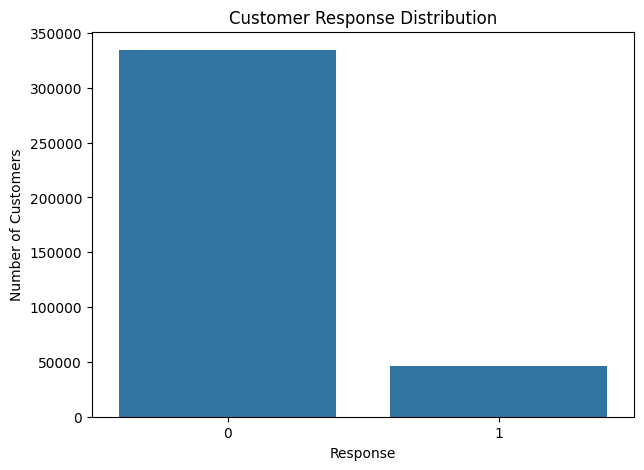

In [11]:
# EDA: Visualizing the distribution of the target variable
plt.figure(figsize=(7, 5))

sns.countplot(data=data, x="Response")

plt.title("Customer Response Distribution")
plt.xlabel("Response")
plt.ylabel("Number of Customers")

plt.show()

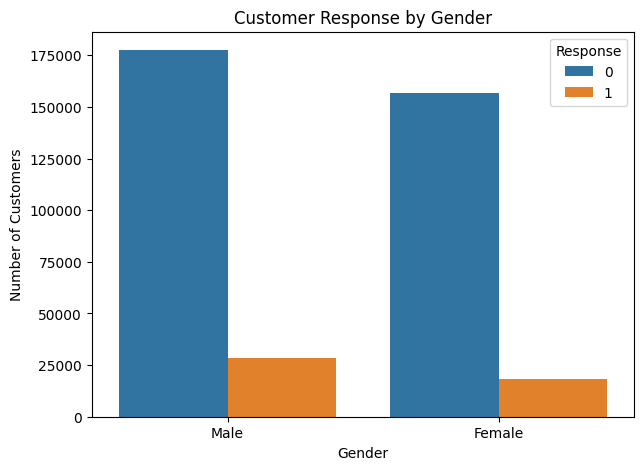

In [12]:
# EDA: analysis of gender vs response
plt.figure(figsize=(7, 5))

sns.countplot(data=data, x="Gender", hue="Response")

plt.title("Customer Response by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

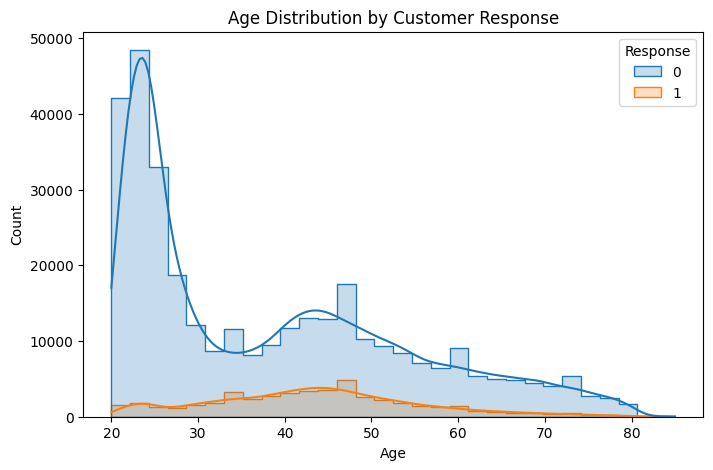

In [13]:
# EDA: Visualizing the distribution of Age by Response
plt.figure(figsize=(8, 5))

sns.histplot(
    data=data,
    x="Age",
    hue="Response",
    bins=30,
    kde=True,
    element="step"
)
plt.title("Age Distribution by Customer Response")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

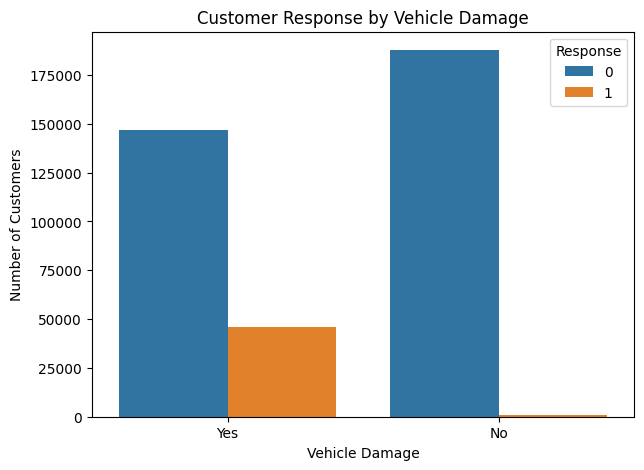

In [14]:
# EDA: Visualizing the distribution of Vehicle Damage by Response
plt.figure(figsize=(7, 5))

sns.countplot(
    data=data,
    x="Vehicle_Damage",
    hue="Response"
)
plt.title("Customer Response by Vehicle Damage")
plt.xlabel("Vehicle Damage")
plt.ylabel("Number of Customers")

plt.show()

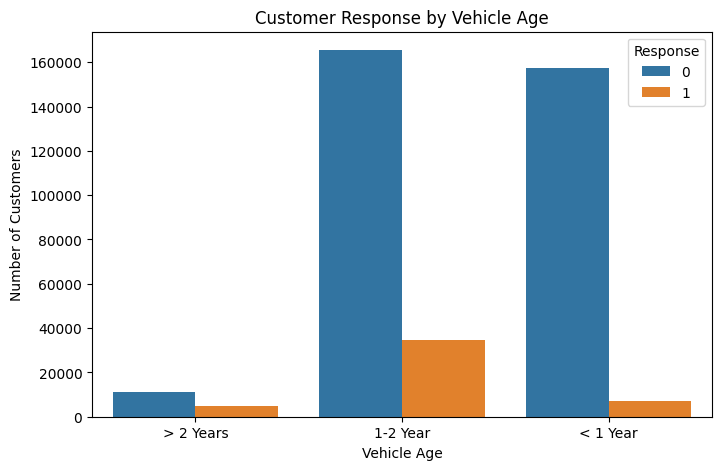

In [15]:
# EDA: Visualizing the distribution of Vehicle Age by Response
plt.figure(figsize=(8, 5))

sns.countplot(
    data=data,
    x="Vehicle_Age",
    hue="Response"
)

plt.title("Customer Response by Vehicle Age")
plt.xlabel("Vehicle Age")
plt.ylabel("Number of Customers")

plt.show()

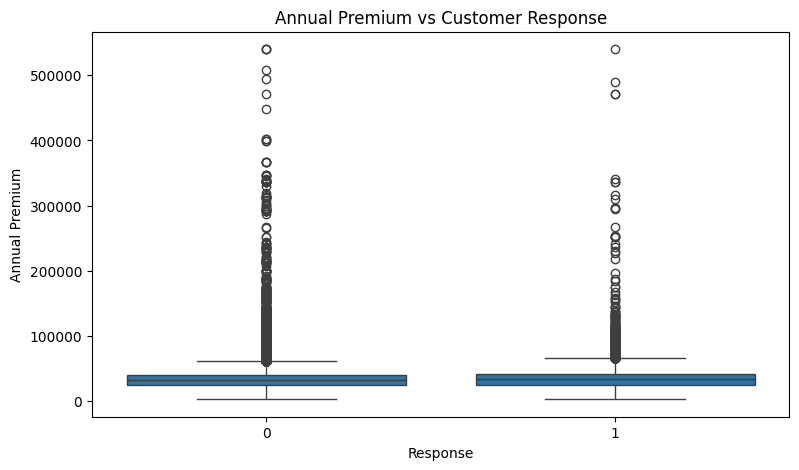

In [16]:
# EDA: Visualizing the distribution of Annual Premium by Response
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=data,
    x="Response",
    y="Annual_Premium"
)

plt.title("Annual Premium vs Customer Response")
plt.xlabel("Response")
plt.ylabel("Annual Premium")

plt.show()

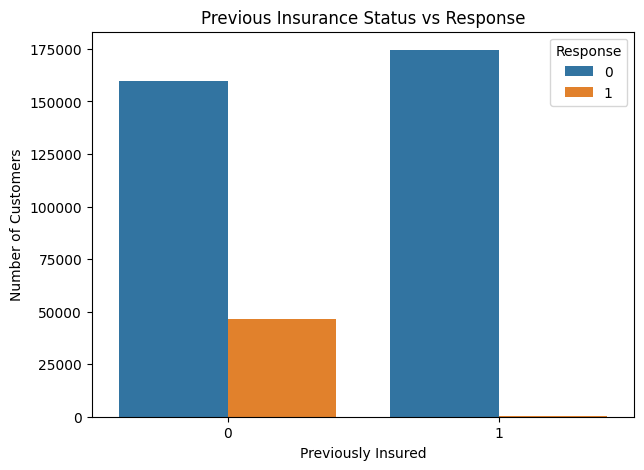

In [17]:
# EDA: Visualizing the distribution of Previous Insurance Status by Response
plt.figure(figsize=(7, 5))

sns.countplot(
    data=data,
    x="Previously_Insured",
    hue="Response"
)

plt.title("Previous Insurance Status vs Response")
plt.xlabel("Previously Insured")
plt.ylabel("Number of Customers")

plt.show()

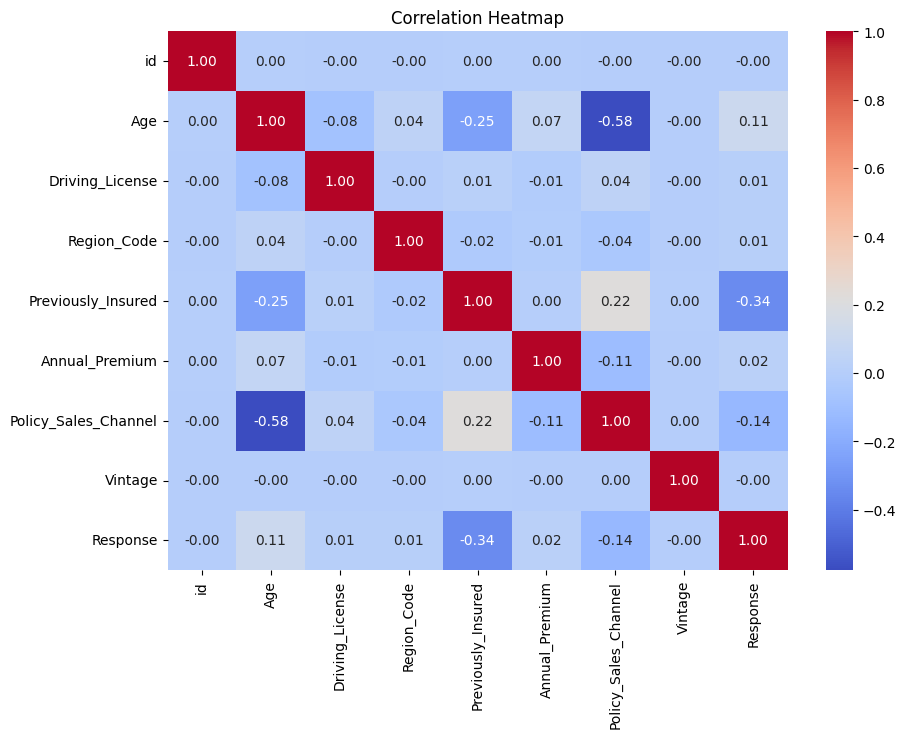

In [18]:
# EDA: Correlation Heatmap
numeric_df = data.select_dtypes(include=np.number)

plt.figure(figsize=(10, 7))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

# Feature Engineering

In [19]:
# Create a copy
data_model = data.copy()

# Vehicle age transformation
data_model["Vehicle_Age_Years"] = data_model["Vehicle_Age"].map({
    "< 1 Year": 0.5,
    "1-2 Year": 1.5,
    "> 2 Years": 3
})

# Age groups
data_model["Age_Group"] = pd.cut(
    data_model["Age"],
    bins=[0, 25, 35, 45, 55, 100],
    labels=[
        "Young",
        "Adult",
        "Middle_Age",
        "Senior",
        "Older"
    ]
)

print(data_model.head())

   id  Gender  Age  Driving_License  Region_Code  Previously_Insured  \
0   1    Male   44                1         28.0                   0   
1   2    Male   76                1          3.0                   0   
2   3    Male   47                1         28.0                   0   
3   4    Male   21                1         11.0                   1   
4   5  Female   29                1         41.0                   1   

  Vehicle_Age Vehicle_Damage  Annual_Premium  Policy_Sales_Channel  Vintage  \
0   > 2 Years            Yes         40454.0                  26.0      217   
1    1-2 Year             No         33536.0                  26.0      183   
2   > 2 Years            Yes         38294.0                  26.0       27   
3    < 1 Year             No         28619.0                 152.0      203   
4    < 1 Year             No         27496.0                 152.0       39   

   Response  Vehicle_Age_Years   Age_Group  
0         1                3.0  Middle_Age  
1 

In [20]:
data_model.shape

(381109, 14)

In [21]:
# Drop the 'id' column
data_model = data_model.drop("id", axis=1)

In [22]:
print(data_model.head())

   Gender  Age  Driving_License  Region_Code  Previously_Insured Vehicle_Age  \
0    Male   44                1         28.0                   0   > 2 Years   
1    Male   76                1          3.0                   0    1-2 Year   
2    Male   47                1         28.0                   0   > 2 Years   
3    Male   21                1         11.0                   1    < 1 Year   
4  Female   29                1         41.0                   1    < 1 Year   

  Vehicle_Damage  Annual_Premium  Policy_Sales_Channel  Vintage  Response  \
0            Yes         40454.0                  26.0      217         1   
1             No         33536.0                  26.0      183         0   
2            Yes         38294.0                  26.0       27         1   
3             No         28619.0                 152.0      203         0   
4             No         27496.0                 152.0       39         0   

   Vehicle_Age_Years   Age_Group  
0                3.0 

In [23]:
# Define features and target
X = data_model.drop("Response", axis=1)
y = data_model["Response"]

print("Features:")
print(X.columns)
print("\nTarget:")
print(y.name)

Features:
Index(['Gender', 'Age', 'Driving_License', 'Region_Code', 'Previously_Insured',
       'Vehicle_Age', 'Vehicle_Damage', 'Annual_Premium',
       'Policy_Sales_Channel', 'Vintage', 'Vehicle_Age_Years', 'Age_Group'],
      dtype='object')

Target:
Response


In [24]:
# Identify categorical and numerical features

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical Features:")
print(categorical_features)
print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['Gender', 'Vehicle_Age', 'Vehicle_Damage', 'Age_Group']

Numerical Features:
['Age', 'Driving_License', 'Region_Code', 'Previously_Insured', 'Annual_Premium', 'Policy_Sales_Channel', 'Vintage', 'Vehicle_Age_Years']


In [25]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (304887, 12)
Testing data: (76222, 12)


In [26]:
# Preprocessing: Standardization for numerical features and One-Hot Encoding for categorical features

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [27]:
print(data_model.head())

   Gender  Age  Driving_License  Region_Code  Previously_Insured Vehicle_Age  \
0    Male   44                1         28.0                   0   > 2 Years   
1    Male   76                1          3.0                   0    1-2 Year   
2    Male   47                1         28.0                   0   > 2 Years   
3    Male   21                1         11.0                   1    < 1 Year   
4  Female   29                1         41.0                   1    < 1 Year   

  Vehicle_Damage  Annual_Premium  Policy_Sales_Channel  Vintage  Response  \
0            Yes         40454.0                  26.0      217         1   
1             No         33536.0                  26.0      183         0   
2            Yes         38294.0                  26.0       27         1   
3             No         28619.0                 152.0      203         0   
4             No         27496.0                 152.0       39         0   

   Vehicle_Age_Years   Age_Group  
0                3.0 

In [28]:
print(preprocessor)

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['Age', 'Driving_License', 'Region_Code',
                                  'Previously_Insured', 'Annual_Premium',
                                  'Policy_Sales_Channel', 'Vintage',
                                  'Vehicle_Age_Years']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['Gender', 'Vehicle_Age', 'Vehicle_Damage',
                                  'Age_Group'])])


In [29]:
preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


# Logistic model

In [30]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier",LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"))
        
    ]
)

print("Training Logistic Regression...")
logistic_model.fit(X_train, y_train)
print("Logistic Regression training completed!")

Training Logistic Regression...
Logistic Regression training completed!


In [31]:
# make predictions
y_pred_lr = logistic_model.predict(X_test)
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

In [32]:
def evaluate_model(model_name, y_test, y_pred, y_prob):

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    print(f"\n===== {model_name} =====")

    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))
    print("ROC-AUC  :", round(roc_auc, 4))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    }

In [33]:
results = []
results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        y_pred_lr,
        y_prob_lr
    )
)


===== Logistic Regression =====
Accuracy : 0.6975
Precision: 0.2773
Recall   : 0.9142
F1 Score : 0.4256
ROC-AUC  : 0.8445

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.67      0.79     66880
           1       0.28      0.91      0.43      9342

    accuracy                           0.70     76222
   macro avg       0.63      0.79      0.61     76222
weighted avg       0.90      0.70      0.75     76222



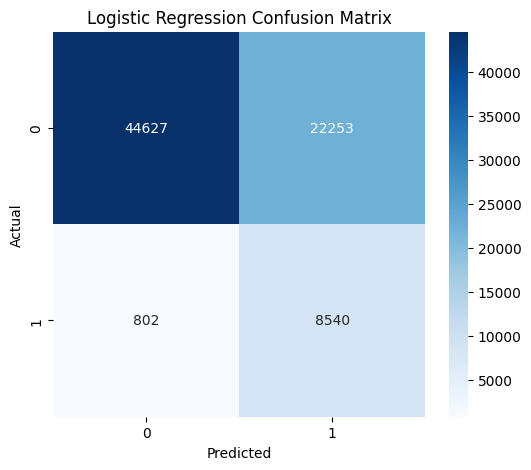

In [34]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Decision tree

In [35]:
decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                max_depth=20,
                random_state=42,
                class_weight="balanced"
            )
        )
    ]
)

print("\nTraining Decision Tree...")

decision_tree_model.fit(X_train, y_train)

print("Decision Tree training completed!")


Training Decision Tree...
Decision Tree training completed!


In [36]:
y_pred_dt = decision_tree_model.predict(X_test)
y_prob_dt = decision_tree_model.predict_proba(X_test)[:, 1]

In [37]:
results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        y_pred_dt,
        y_prob_dt
    )
)


===== Decision Tree =====
Accuracy : 0.7353
Precision: 0.2898
Recall   : 0.7993
F1 Score : 0.4254
ROC-AUC  : 0.7855

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.73      0.83     66880
           1       0.29      0.80      0.43      9342

    accuracy                           0.74     76222
   macro avg       0.63      0.76      0.63     76222
weighted avg       0.88      0.74      0.78     76222



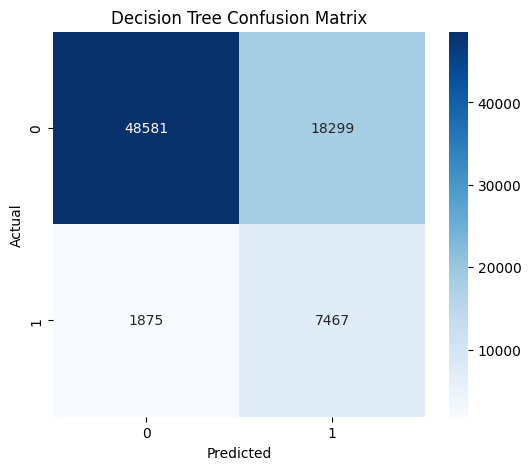

In [38]:
cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [39]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
             "classifier",
            RandomForestClassifier(
                n_estimators=500,
                max_depth=15,
                min_samples_split=2,
                min_samples_leaf=1,
                class_weight="balanced",
                n_jobs=-1,
                random_state=42
            )
        )
    ]
)

print("\nTraining Random Forest...")

random_forest_model.fit(X_train, y_train)

print("Random Forest training completed!")


Training Random Forest...
Random Forest training completed!


In [40]:
y_pred_rf = random_forest_model.predict(X_test)

y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

In [41]:
results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        y_pred_rf,
        y_prob_rf
    )
)


===== Random Forest =====
Accuracy : 0.7233
Precision: 0.292
Recall   : 0.8826
F1 Score : 0.4388
ROC-AUC  : 0.8529

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.70      0.82     66880
           1       0.29      0.88      0.44      9342

    accuracy                           0.72     76222
   macro avg       0.63      0.79      0.63     76222
weighted avg       0.89      0.72      0.77     76222



In [42]:
results_df = pd.DataFrame(results)

print("\n===== MODEL COMPARISON =====")
print(results_df)


===== MODEL COMPARISON =====
                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression  0.697528   0.277336  0.914151  0.425564  0.844491
1        Decision Tree  0.735326   0.289801  0.799294  0.425373  0.785514
2        Random Forest  0.723282   0.291962  0.882573  0.438774  0.852892


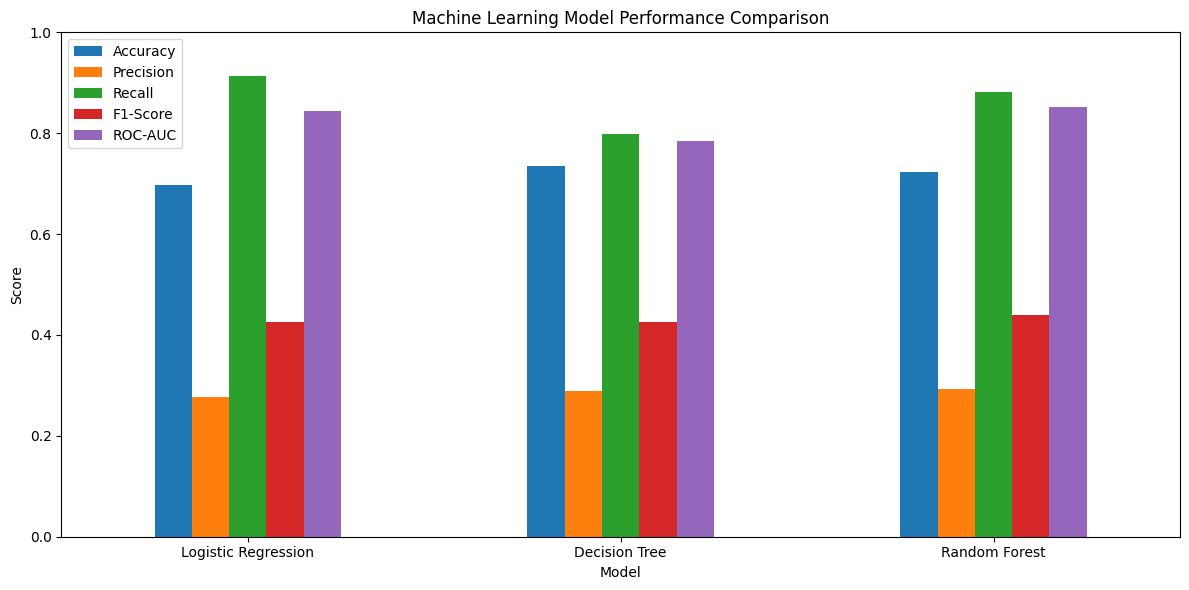

In [43]:
results_plot = results_df.set_index("Model")

results_plot[
    ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Machine Learning Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.ylim(0, 1)

plt.legend()
plt.tight_layout()
plt.show()

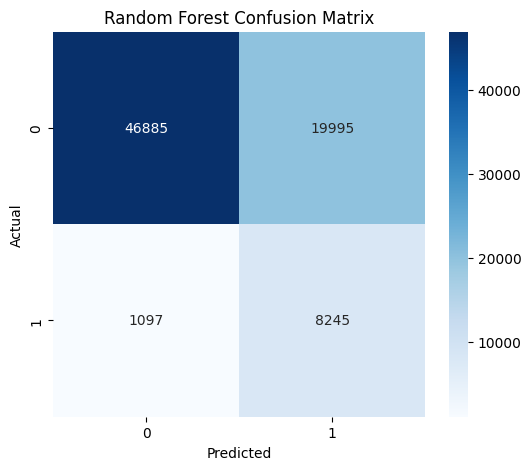

In [44]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

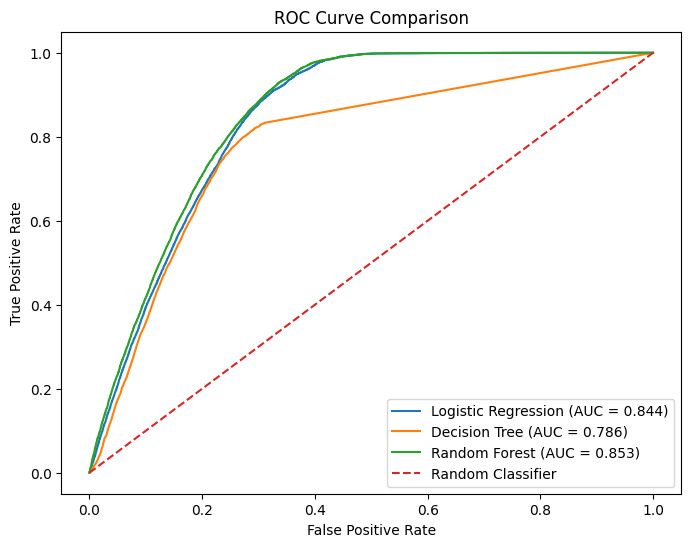

In [45]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.3f})"
)

plt.plot(
    fpr_dt,
    tpr_dt,
    label=f"Decision Tree (AUC = {roc_auc_score(y_test, y_prob_dt):.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.show()

In [46]:
# Get trained preprocessor
trained_preprocessor = random_forest_model.named_steps["preprocessor"]

# Get trained Random Forest
trained_rf = random_forest_model.named_steps["classifier"]

# Get feature names
feature_names = trained_preprocessor.get_feature_names_out()

# Get importance
importance = trained_rf.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 20 Important Features:")
print(feature_importance_df.head(20))


Top 20 Important Features:
                       Feature  Importance
14     cat__Vehicle_Damage_Yes    0.229491
13      cat__Vehicle_Damage_No    0.223315
3      num__Previously_Insured    0.210969
0                     num__Age    0.067729
5    num__Policy_Sales_Channel    0.048914
6                 num__Vintage    0.037962
4          num__Annual_Premium    0.034618
11   cat__Vehicle_Age_< 1 Year    0.030721
2             num__Region_Code    0.030431
7       num__Vehicle_Age_Years    0.029961
19        cat__Age_Group_Young    0.022238
10   cat__Vehicle_Age_1-2 Year    0.008294
17        cat__Age_Group_Older    0.007532
15        cat__Age_Group_Adult    0.003875
16   cat__Age_Group_Middle_Age    0.003855
9             cat__Gender_Male    0.002657
8           cat__Gender_Female    0.002604
18       cat__Age_Group_Senior    0.002072
12  cat__Vehicle_Age_> 2 Years    0.001852
1         num__Driving_License    0.000912


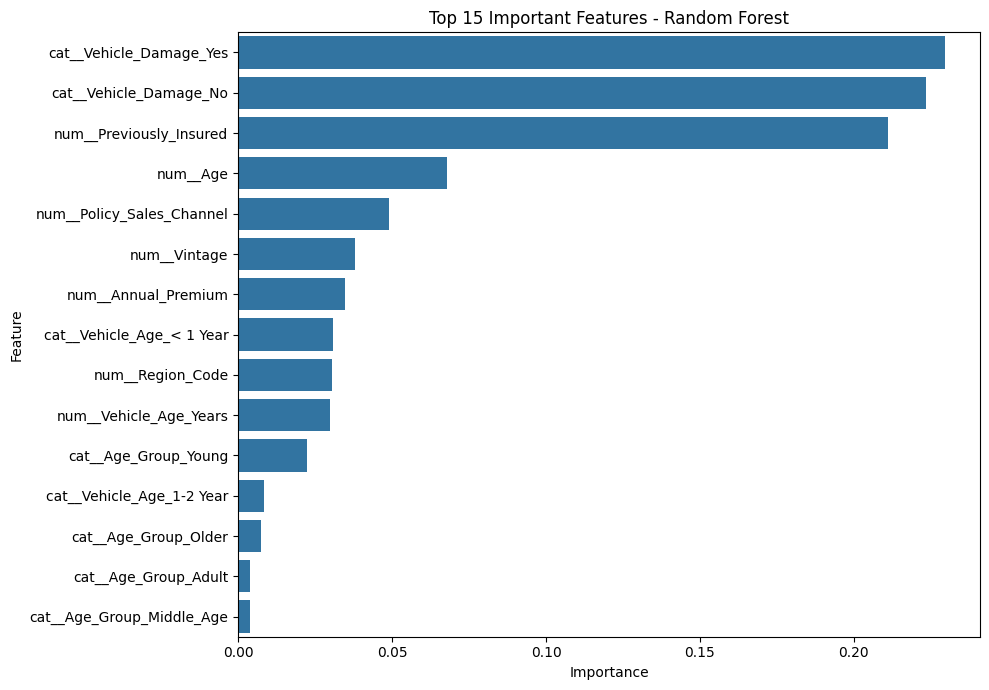

In [47]:
top_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features - Random Forest")

plt.tight_layout()
plt.show()

In [48]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

In [49]:
# ============================================
# RANDOM FOREST HYPERPARAMETER TUNING
# ============================================

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                random_state=42,
                n_jobs=-1,
                class_weight="balanced"
            )
        )
    ]
)

In [50]:
param_distributions = {
    "classifier__n_estimators": [100, 150, 200, 250],
    "classifier__max_depth": [8, 10, 12, 15, 20, None],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__max_features": ["sqrt", "log2"]
}

In [51]:
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

In [52]:
random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=10,
    scoring="roc_auc",
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [53]:
print("\nStarting Random Forest Hyperparameter Tuning...")

random_search.fit(X_train, y_train)

print("\nHyperparameter tuning completed!")


Starting Random Forest Hyperparameter Tuning...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Hyperparameter tuning completed!


In [54]:
print("\nBest Parameters:")
print(random_search.best_params_)

print("\nBest Cross-Validation ROC-AUC:")
print(random_search.best_score_)


Best Parameters:
{'classifier__n_estimators': 200, 'classifier__min_samples_split': 10, 'classifier__min_samples_leaf': 1, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 12}

Best Cross-Validation ROC-AUC:
0.8533854659638062


In [55]:
best_rf_model = random_search.best_estimator_

y_pred_tuned = best_rf_model.predict(X_test)

y_prob_tuned = best_rf_model.predict_proba(X_test)[:, 1]

In [56]:
tuned_rf_results = evaluate_model(
    "Tuned Random Forest",
    y_test,
    y_pred_tuned,
    y_prob_tuned
)

print("\nTuned Random Forest Results:")
print(tuned_rf_results)


===== Tuned Random Forest =====
Accuracy : 0.701
Precision: 0.281
Recall   : 0.9236
F1 Score : 0.4309
ROC-AUC  : 0.8544

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.67      0.80     66880
           1       0.28      0.92      0.43      9342

    accuracy                           0.70     76222
   macro avg       0.63      0.80      0.61     76222
weighted avg       0.90      0.70      0.75     76222


Tuned Random Forest Results:
{'Model': 'Tuned Random Forest', 'Accuracy': 0.7010049591981318, 'Precision': 0.28100573215216257, 'Recall': 0.9235709698137444, 'F1-Score': 0.43090445987114817, 'ROC-AUC': 0.8543612223159494}


In [57]:
comparison = pd.DataFrame([
    {
        "Model": "Original Random Forest",
        "Accuracy": accuracy_score(y_test, y_pred_rf),
        "Precision": precision_score(y_test, y_pred_rf),
        "Recall": recall_score(y_test, y_pred_rf),
        "F1-Score": f1_score(y_test, y_pred_rf),
        "ROC-AUC": roc_auc_score(y_test, y_prob_rf)
    },
    tuned_rf_results
])

print("\n===== ORIGINAL VS TUNED RANDOM FOREST =====")
print(comparison)


===== ORIGINAL VS TUNED RANDOM FOREST =====
                    Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Original Random Forest  0.723282   0.291962  0.882573  0.438774  0.852892
1     Tuned Random Forest  0.701005   0.281006  0.923571  0.430904  0.854361


# save the best model

In [58]:
import os
import joblib

os.makedirs("model", exist_ok=True)

joblib.dump(
    best_rf_model,
    "model/insurance_response_model.pkl"
)

print("Final model saved successfully!")

Final model saved successfully!


In [59]:
import pandas as pd
import joblib
import time

print("Starting program...")

start = time.time()

print("Loading model...")

model = joblib.load(
    "model/insurance_response_model.pkl"
)

print(f"Model loaded in {time.time() - start:.2f} seconds")

print("Program ready!")

Starting program...
Loading model...
Model loaded in 0.65 seconds
Program ready!
